In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [9]:
f = h5py.File("data/hubbard_tebd.hdf5", "r")
exact_energy = f["exact_energy"][()]
dmrg_bond_dims = f["dmrg_bond_dims"][:]
print(dmrg_bond_dims)
tebd_bond_dims = f["tebd_bond_dims"][:]
print(tebd_bond_dims)
dmrg_energies = f["dmrg_energies"][:]
tebd_energies = f["tebd_energies"][:, :]
energies_u = f["energies_u"][:]
h_u = f["h_u"][:, :]
s_u = f["s_u"][:, :]
all_tebd_h = f["all_tebd_h"][:, :, :]
all_tebd_s = f["all_tebd_s"][:, :, :]
bond_sizes = f["bond_sizes"][:, :, :]
f.close()

[ 5 10 20 30]
[ 5 10 20 30]


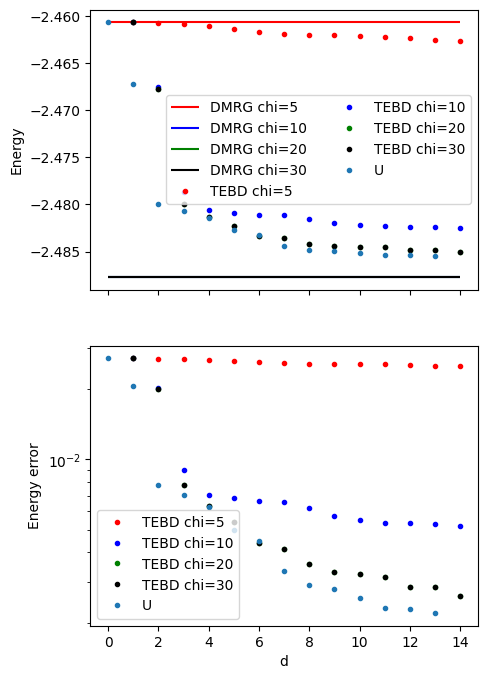

In [21]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(5., 8.))

d_max = tebd_energies.shape[-1]

energy_colors = ["red", "blue", "green", "black"]
for i, (chi, energy) in enumerate(zip(dmrg_bond_dims, dmrg_energies)):
    ax[0].hlines(energy, 0., d_max, color=energy_colors[i], label=f"DMRG chi={chi}")

for i in range(len(tebd_bond_dims)):
    ax[0].plot(range(1, d_max+1), tebd_energies[i, :], '.', color=energy_colors[i], label=f"TEBD chi={tebd_bond_dims[i]}")

ax[0].plot(energies_u, '.', label="U")

# ax.set_ylim(-2.6, -2.4)
tebd_errs = np.abs(tebd_energies - exact_energy)
u_errs = np.abs(energies_u - exact_energy)

for i in range(len(tebd_bond_dims)):
    ax[1].plot(range(1, d_max+1), tebd_errs[i, :], '.', color=energy_colors[i], label=f"TEBD chi={tebd_bond_dims[i]}")
ax[1].plot(u_errs, '.', label="U")

ax[0].legend(ncols=2)
ax[0].set_ylabel("Energy")
ax[1].legend()
ax[1].set_yscale('log')
ax[1].set_ylabel("Energy error")
ax[1].set_xlabel("d")

plt.savefig("data/hubbard.pdf")